In [42]:
import numpy as np
import cv2
from matplotlib import pyplot as plt 

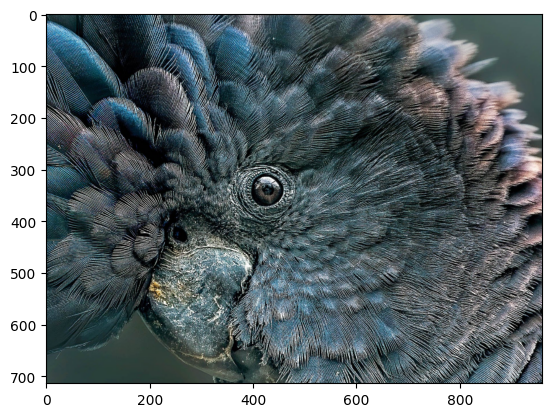

In [43]:
image = cv2.imread('image.png')
image= image[:, :, ::-1]
rows = image.shape[0]
cols = image.shape[1]
plt.imshow(image)


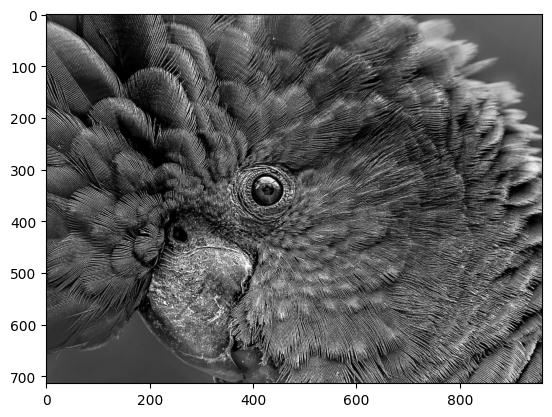

In [44]:
b,r,g = cv2.split(image)
plt.imshow(r, cmap='gray')

In [45]:
print(r)

[[ 53 106  59 ... 105 105 105]
 [ 14  77 101 ... 105 105 105]
 [ 25  54  85 ... 105 105 105]
 ...
 [ 75  75  75 ...  75  93 139]
 [ 75  75  75 ...  53  29  30]
 [ 75  75  75 ...  24   7   1]]


In [50]:
dx = 10  
dy = 20
shifted = np.zeros_like(r)
print(shifted)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


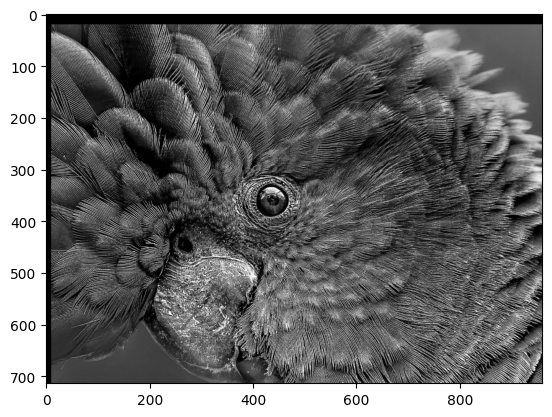

In [52]:

shifted[dy:rows, dx:cols] = r[0:rows - dy, 0:cols - dx]
plt.imshow(shifted,cmap='gray')

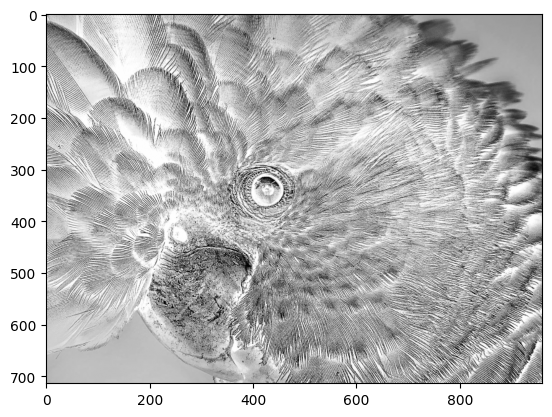

In [55]:
inverted = 255 - r
plt.imshow(inverted, cmap = 'gray')

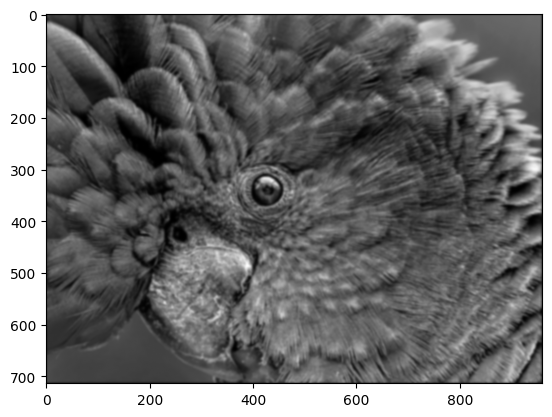

In [80]:
kernel_size = 11   # ядро 11x11
sigma = 2.0        # стандартне відхилення
pad = kernel_size // 2
blurred = np.zeros_like(r, dtype=np.float32)
ax = np.linspace(-(kernel_size-1)//2, (kernel_size-1)//2, kernel_size)
xx, yy = np.meshgrid(ax, ax)
kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
kernel = kernel / np.sum(kernel) 

padded = np.pad(r, pad_width=pad, mode='constant', constant_values=0)

for i in range(rows):
    for j in range(cols):
        region = padded[i:i+kernel_size, j:j+kernel_size]
        blurred[i,j] = np.sum(region * kernel)

blurred = blurred.astype(np.uint8)
plt.imshow(blurred, cmap='gray')   


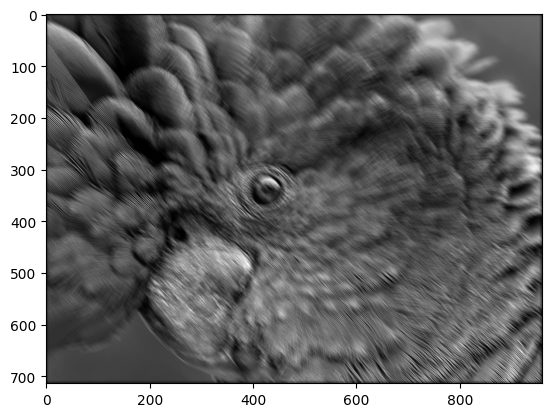

In [81]:
kernel_size = 11
pad = kernel_size // 2
kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
np.fill_diagonal(kernel, 1.0)
kernel /= kernel.sum() 

blur_diag = np.zeros_like(r, dtype=np.float32)
for i in range(rows):
    for j in range(cols):
        region = padded[i:i+kernel_size, j:j+kernel_size]
        blur_diag[i,j] = np.sum(region * kernel)
blur_diag = np.clip(blur_diag,0,255).astype(np.uint8)
plt.imshow(blur_diag, cmap='gray')

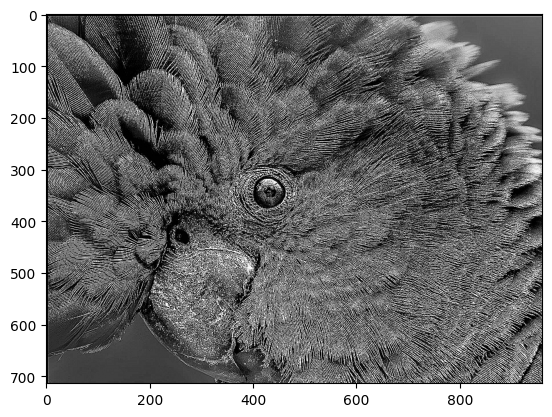

In [ ]:
sharpen_kernel = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]], dtype=np.float32)
pad = 1
sharp = np.zeros_like(r, dtype=np.float32)

for i in range(rows):
    for j in range(cols):
        region = padded[i:i+3, j:j+3]
        sharp[i,j] = np.sum(region * sharpen_kernel)

sharp = np.clip(sharp,0,255).astype(np.uint8)

plt.imshow(sharp, cmap='gray')

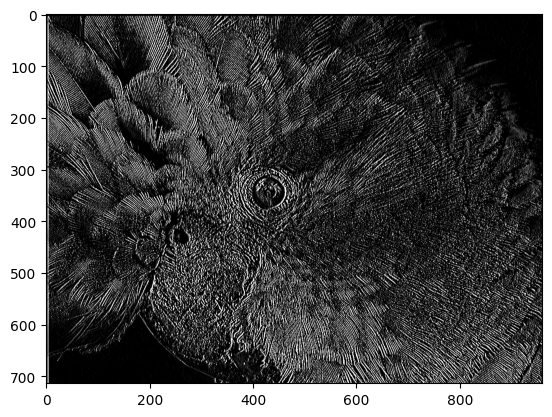

In [84]:
sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]], dtype=np.float32)
pad = 1
sobel_img = np.zeros_like(r, dtype=np.float32)
for i in range(rows):
    for j in range(cols):
        region = padded[i:i+3,j:j+3]
        sobel_img[i,j] = np.sum(region*sobel_x)

sobel_img = np.clip(sobel_img,0,255).astype(np.uint8)
plt.imshow(sobel_img, cmap='gray')

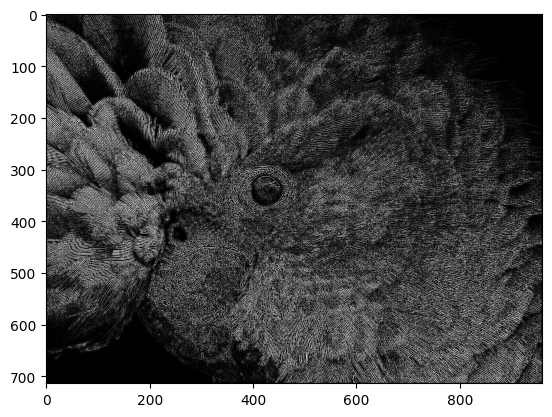

In [90]:
laplacian_kernel = np.array([[0,1,0],
                             [1,-4,1],
                             [0,1,0]], dtype=np.float32)

pad = 1
padded = np.pad(r, pad, mode='constant', constant_values=0)
edge_img = np.zeros_like(r, dtype=np.float32)

for i in range(rows):
    for j in range(cols):
        region = padded[i:i+3,j:j+3]
        edge_img[i,j] = np.sum(region*laplacian_kernel)

edge_img = np.clip(edge_img,0,255).astype(np.uint8)
plt.imshow(edge_img, cmap='gray')

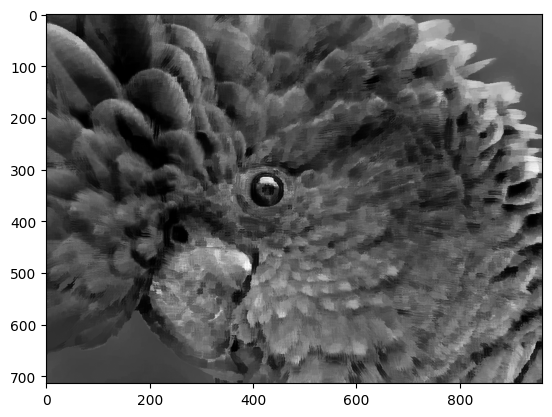

In [89]:
kernel = np.zeros((5,5), dtype=np.float32)
np.fill_diagonal(kernel, 0.5)  # половина впливу по діагоналі
k = 5  # половина розміру вікна, повне вікно буде 2k+1 = 11
pad = k
padded = np.pad(r, pad, mode='reflect')  # відображення країв

kuwahara = np.zeros_like(r, dtype=np.float32)

for i in range(rows):
    for j in range(cols):
        # Вікно навколо пікселя
        window = padded[i:i+2*k+1, j:j+2*k+1]
        mid = k

        # 4 квадранти
        q1 = window[0:mid+1, 0:mid+1]       # верхній лівий
        q2 = window[0:mid+1, mid:]          # верхній правий
        q3 = window[mid:, 0:mid+1]          # нижній лівий
        q4 = window[mid:, mid:]             # нижній правий

        quadrants = [q1, q2, q3, q4]

        # обчислюємо дисперсію та середнє
        mean_vals = [np.mean(q) for q in quadrants]
        var_vals = [np.var(q) for q in quadrants]

        # обираємо середнє з найменшою дисперсією
        kuwahara[i,j] = mean_vals[np.argmin(var_vals)]

kuwahara = np.clip(kuwahara,0,255).astype(np.uint8)
plt.imshow(kuwahara, cmap='gray')